# Data cleaning

Kutubxonalarni yuklash va ma'lumotlarning dastlabki holatini o'rganish.
Birinchi navbatda pandas kutubxonasini yuklab, ma'lumotlarni o'qiymiz. Jadvallarning o'lchamini (qator va ustunlar sonini) chiqarib, ularning qanchalik kattaligini ko'zdan kechiramiz. Ustun nomlaridagi xatoliklarni to'g'rilab olamiz.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 

In [2]:
# Ma'lumotlarni yuklash
products = pd.read_csv('data/products.csv')
sales = pd.read_csv('data/sales.csv')

# Dastlabki o'lchamlarni ko'rish
print("Dastlabki products jadvali o'lchami:", products.shape)
print("Dastlabki sales jadvali o'lchami:", sales.shape)

# Ustun nomlarini standartlashtirish
products.rename(columns={'cost_prise': 'cost_price'}, inplace=True)
sales.rename(columns={'regiaon': 'region', 'pyment_type': 'payment_type'}, inplace=True)

Dastlabki products jadvali o'lchami: (10, 4)
Dastlabki sales jadvali o'lchami: (120000, 9)


Bo'sh (Missing) qiymatlarni tekshirish va tozalash.
Ma'lumotlar tahlilida bo'sh qiymatlar xato natijalarga olib kelishi mumkin. Avval har bir jadvalda nechta qatorda bo'sh qiymat borligini aniqlaymiz. Keyin ularni olib tashlab, qancha qator qisqarganini ekranga chiqaramiz.

In [3]:
# Bo'sh qiymatlarni sanash
print("Products jadvalidagi bo'sh qiymatlar soni:\n", products.isnull().sum())
print("\nSales jadvalidagi bo'sh qiymatlar soni:\n", sales.isnull().sum())

# Bo'sh qiymati mavjud qatorlarni o'chirish
products.dropna(inplace=True)
sales.dropna(inplace=True)

print("\nBo'sh qiymatlar tozalanagandan keyingi o'lchamlar:")
print("Products:", products.shape)
print("Sales:", sales.shape)

Products jadvalidagi bo'sh qiymatlar soni:
 product_id      0
product_name    0
category        0
cost_price      0
dtype: int64

Sales jadvalidagi bo'sh qiymatlar soni:
 order_id        0
customer_id     0
product_id      0
category        0
price           0
quantity        0
order_date      0
region          0
payment_type    0
dtype: int64

Bo'sh qiymatlar tozalanagandan keyingi o'lchamlar:
Products: (10, 4)
Sales: (120000, 9)


Takroriy (Duplicate) qatorlarni aniqlash va o'chirish.
Bazada bir xil ma'lumotlar ikki marta tushib qolgan bo'lishi mumkin. Bunday yozuvlar sotuvlar hajmini sun'iy ravishda oshirib ko'rsatadi. Takroriy qatorlar sonini aniqlab, ularni jadvaldan o'chiramiz.

In [4]:
# Dublikatlarni sanash
products_duplicates = products.duplicated().sum()
sales_duplicates = sales.duplicated().sum()

print(f"Products jadvalidagi takroriy qatorlar soni: {products_duplicates}")
print(f"Sales jadvalidagi takroriy qatorlar soni: {sales_duplicates}")

# Dublikatlarni o'chirish
products.drop_duplicates(inplace=True)
sales.drop_duplicates(inplace=True)

print("\nTakroriy qatorlar o'chirilgandan keyingi o'lchamlar:")
print("Products:", products.shape)
print("Sales:", sales.shape)

Products jadvalidagi takroriy qatorlar soni: 0
Sales jadvalidagi takroriy qatorlar soni: 0

Takroriy qatorlar o'chirilgandan keyingi o'lchamlar:
Products: (10, 4)
Sales: (120000, 9)


Noto'g'ri narx yoki miqdorlarni aniqlash va tozalash.
Mantiqan, mahsulot narxi va sotilgan miqdor noldan katta bo'lishi shart. Agar ma'lumotlar bazasida 0 yoki undan kichik sonlar bo'lsa, bu kiritishdagi xatolik hisoblanadi. Bunday xato qatorlar sonini topib, ularni filtarlaymiz.

In [5]:
# Noto'g'ri qiymatlarni aniqlash
invalid_sales = sales[(sales['price'] <= 0) | (sales['quantity'] <= 0)].shape[0]
invalid_products = products[products['cost_price'] <= 0].shape[0]

print(f"Sales jadvalidagi noto'g'ri narx/miqdorga ega qatorlar soni: {invalid_sales}")
print(f"Products jadvalidagi noto'g'ri tannarxga ega qatorlar soni: {invalid_products}")

# Faqat to'g'ri qiymatlarni saqlab qolish
sales = sales[(sales['price'] > 0) & (sales['quantity'] > 0)]
products = products[products['cost_price'] > 0]

print("\nNoto'g'ri ma'lumotlar tozalangandan keyingi o'lchamlar:")
print("Products:", products.shape)
print("Sales:", sales.shape)

Sales jadvalidagi noto'g'ri narx/miqdorga ega qatorlar soni: 0
Products jadvalidagi noto'g'ri tannarxga ega qatorlar soni: 0

Noto'g'ri ma'lumotlar tozalangandan keyingi o'lchamlar:
Products: (10, 4)
Sales: (120000, 9)


Sanalarni normalize qilish.
Order_date ustuni odatda matn (string) ko'rinishida bo'ladi. Uni maxsus datetime formatiga o'tkazishimiz kerak, shunda vaqt boyicha tahlillar (masalan, oylik tushum) qilish osonlashadi. O'tkazish paytida xatolik beruvchi (noto'g'ri yozilgan) sanalarni ajratib olib, ularni ham tozalaymiz.

In [6]:
# Sanalarni o'zgartirishdan oldin ma'lumot turini ko'rish
print("Dastlabki order_date turi:", sales['order_date'].dtype)

# Datetime formatiga o'tkazish (xato sanalar NaT ga aylanadi)
sales['order_date'] = pd.to_datetime(sales['order_date'], errors='coerce')

# NaT (Not a Time) ga aylangan xato sanalar sonini aniqlash va o'chirish
invalid_dates = sales['order_date'].isnull().sum()
print(f"Noto'g'ri formatdagi sanalar soni (va o'chirildi): {invalid_dates}")

sales.dropna(subset=['order_date'], inplace=True)
print("Yangi order_date turi:", sales['order_date'].dtype)



Dastlabki order_date turi: str
Noto'g'ri formatdagi sanalar soni (va o'chirildi): 0
Yangi order_date turi: datetime64[us]


Moliyaviy ko'rsatkichlarni hisoblash: Revenue va Profit.
Yakuniy qadamda mahsulotlar tannarxini olish uchun jadvallarni birlashtiramiz. Birlashtirilgan jadvalda har bir xarid uchun umumiy tushum (Revenue) va sof foyda (Profit) hisoblanadi. Foydani hisoblashda mantiqan umumiy tushumdan barcha sotilgan mahsulotlarning umumiy tannarxi (cost_price * quantity) ayiriladi.

In [7]:
# Jadvallarni product_id orqali birlashtirish (chapga qo'shish)
# Category ikkala jadvalda bo'lgani uchun chalkashlik bo'lmasligi uchun uni products dan olmaymiz
merged_df = sales.merge(products[['product_id', 'cost_price']], on='product_id', how='left')

# Birlashtirish natijasida cost_price topilmagan yozuvlar bor-yo'qligini tekshirish
missing_costs = merged_df['cost_price'].isnull().sum()
print(f"Bazasida tannarxi topilmagan sotuvlar soni: {missing_costs}")
merged_df.dropna(subset=['cost_price'], inplace=True)

# Tushum va foydani hisoblash
merged_df['revenue'] = merged_df['price'] * merged_df['quantity']

# Umumiy tushumdan umumiy tannarxni ayirish
merged_df['profit'] = merged_df['revenue'] - (merged_df['cost_price'] * merged_df['quantity'])

# Natijani tekshirish
print("\nYakuniy jadvalning dastlabki 5 qatori:")
print(merged_df[['order_id', 'product_id', 'quantity', 'revenue', 'profit']].head())

Bazasida tannarxi topilmagan sotuvlar soni: 0

Yakuniy jadvalning dastlabki 5 qatori:
   order_id product_id  quantity  revenue  profit
0         1       P004         5   410.70  135.70
1         2       P007         2     0.72    0.12
2         3       P009         1    38.60   13.60
3         4       P003         5   277.40   77.40
4         5       P001         2  1792.82  592.82


# Dada Analitics

Kerakli kutubxonalarni yuklash va Biznes Metrikalarni hisoblash.
Ma'lumotlarni vizualizatsiya qilish uchun Pythonning matplotlib va seaborn kutubxonalaridan foydalanamiz. Birinchi qadamda biznesning umumiy holatini ko'rsatuvchi tushum, foyda va xarajatni hisoblaymiz. Ularning nisbatini yaqqol ko'rish uchun ustunli grafik (bar chart) chizamiz. Bu rahbariyatga pul qayerdan kelib, qanchasi sof foyda bo'lib qolayotganini tushunishga yordam beradi.

Umumiy tushum (Total Revenue): 63,338,820.15
Umumiy foyda (Total Profit): 19,682,845.45
Foyda marjasi (Profit Margin): 31.08%



C:\Users\Javoxir\AppData\Local\Temp\ipykernel_16104\1323900310.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Total Revenue', 'Total Cost', 'Total Profit'],


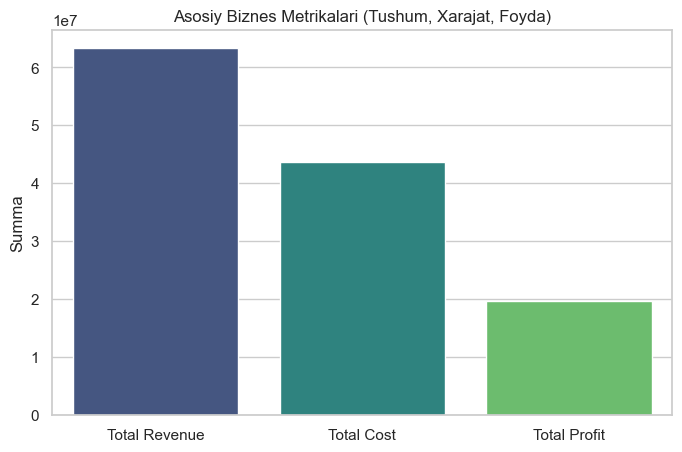

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklar uslubini zamonaviy va toza qilib sozlash
sns.set_theme(style="whitegrid")

# Metrikalarni hisoblash
total_revenue = merged_df['revenue'].sum()
total_profit = merged_df['profit'].sum()
total_cost = total_revenue - total_profit
profit_margin = (total_profit / total_revenue) * 100

# Raqamli natijalarni konsolga chiqarish
print(f"Umumiy tushum (Total Revenue): {total_revenue:,.2f}")
print(f"Umumiy foyda (Total Profit): {total_profit:,.2f}")
print(f"Foyda marjasi (Profit Margin): {profit_margin:.2f}%\n")

# Vizualizatsiya: Tushum tarkibi
plt.figure(figsize=(8, 5))
# Daromad, Xarajat va Foydani yonma-yon solishtirish
sns.barplot(x=['Total Revenue', 'Total Cost', 'Total Profit'], 
            y=[total_revenue, total_cost, total_profit], 
            palette='viridis')

plt.title('Asosiy Biznes Metrikalari (Tushum, Xarajat, Foyda)')
plt.ylabel('Summa')
plt.show()

Samaradorlikni baholash (Performance Analytics).
Tizimdagi kuchli va zaif nuqtalarni aniqlash biznes strategiyasi uchun muhim. Ushbu qadamda Top 10 mahsulotni, toifalar bo'yicha foydani va hududlar bo'yicha tushumni hisoblaymiz. Bularni bitta umumiy oynada 3 ta alohida gorizontal ustunli grafikda tasvirlaymiz. Gorizontal grafiklar uzun nomli mahsulot va hududlarni o'qish uchun eng qulay usul hisoblanadi. Shunday qilib, qaysi hudud eng past ko'rsatkichga ega ekanligi avtomatik yaqqol ko'rinadi.

Eng foydali kategoriya: Electronics
Eng past performance hudud: Andijan 



C:\Users\Javoxir\AppData\Local\Temp\ipykernel_16104\2549704135.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_products.values, y=top_10_products.index, ax=axes[0], palette='Blues_r')
C:\Users\Javoxir\AppData\Local\Temp\ipykernel_16104\2549704135.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.values, y=category_profit.index, ax=axes[1], palette='Greens_r')
C:\Users\Javoxir\AppData\Local\Temp\ipykernel_16104\2549704135.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_revenue.values, y=region_

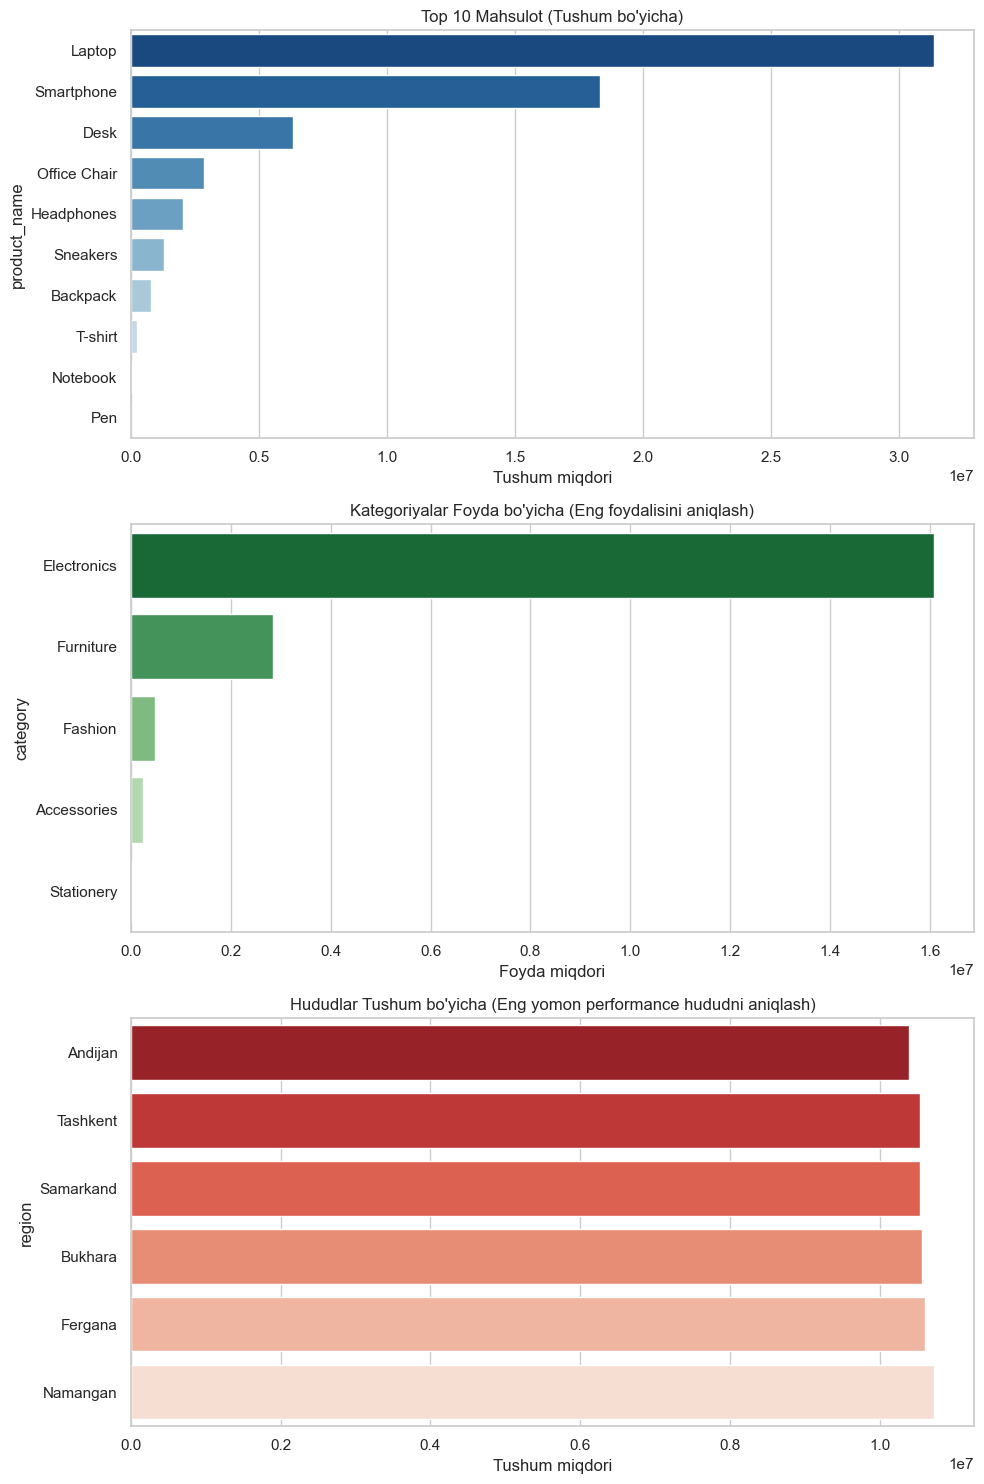

In [9]:
# Agar product_name ustuni yo'q bo'lsa, uni products jadvalidan olib kelamiz
if 'product_name' not in merged_df.columns:
    merged_df = merged_df.merge(products[['product_id', 'product_name']], on='product_id', how='left')

# 1. Top 10 mahsulot (Tushum bo'yicha)
top_10_products = merged_df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

# 2. Toifalar bo'yicha foyda (Profit)
category_profit = merged_df.groupby('category')['profit'].sum().sort_values(ascending=False)

# 3. Hududlar bo'yicha tushum (Revenue) - Eng pastini ko'rish uchun o'sish tartibida taxlaymiz
region_revenue = merged_df.groupby('region')['revenue'].sum().sort_values(ascending=True)

# Natijalarni konsolga chiqarish
print("Eng foydali kategoriya:", category_profit.index[0])
print("Eng past performance hudud:", region_revenue.index[0], "\n")

# Vizualizatsiya oynasini tayyorlash (3 qator, 1 ustun)
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Top 10 mahsulot grafigi
sns.barplot(x=top_10_products.values, y=top_10_products.index, ax=axes[0], palette='Blues_r')
axes[0].set_title("Top 10 Mahsulot (Tushum bo'yicha)")
axes[0].set_xlabel("Tushum miqdori")

# Kategoriyalar foyda bo'yicha
sns.barplot(x=category_profit.values, y=category_profit.index, ax=axes[1], palette='Greens_r')
axes[1].set_title("Kategoriyalar Foyda bo'yicha (Eng foydalisini aniqlash)")
axes[1].set_xlabel("Foyda miqdori")

# Hududlar tushum bo'yicha
sns.barplot(x=region_revenue.values, y=region_revenue.index, ax=axes[2], palette='Reds_r')
axes[2].set_title("Hududlar Tushum bo'yicha (Eng yomon performance hududni aniqlash)")
axes[2].set_xlabel("Tushum miqdori")

# Grafiklarni tartibli joylashtirish
plt.tight_layout()
plt.show()

Trendlar va xatti-harakatlar taqsimoti (Trends and Distributions).
Vaqt o'tishi bilan savdolar qanday o'zgarayotganini tushunish uchun oylik tushum trendini chiziqli grafikda (line chart) chizamiz. Mijozlarning xarid odatlarini aniqlash uchun ish kunlari va dam olish kunlaridagi savdo hajmini, shuningdek to'lov turlarini (naqd, karta va h.k.) doiraviy diagrammalarda (pie chart) foiz hisobida tasvirlaymiz.

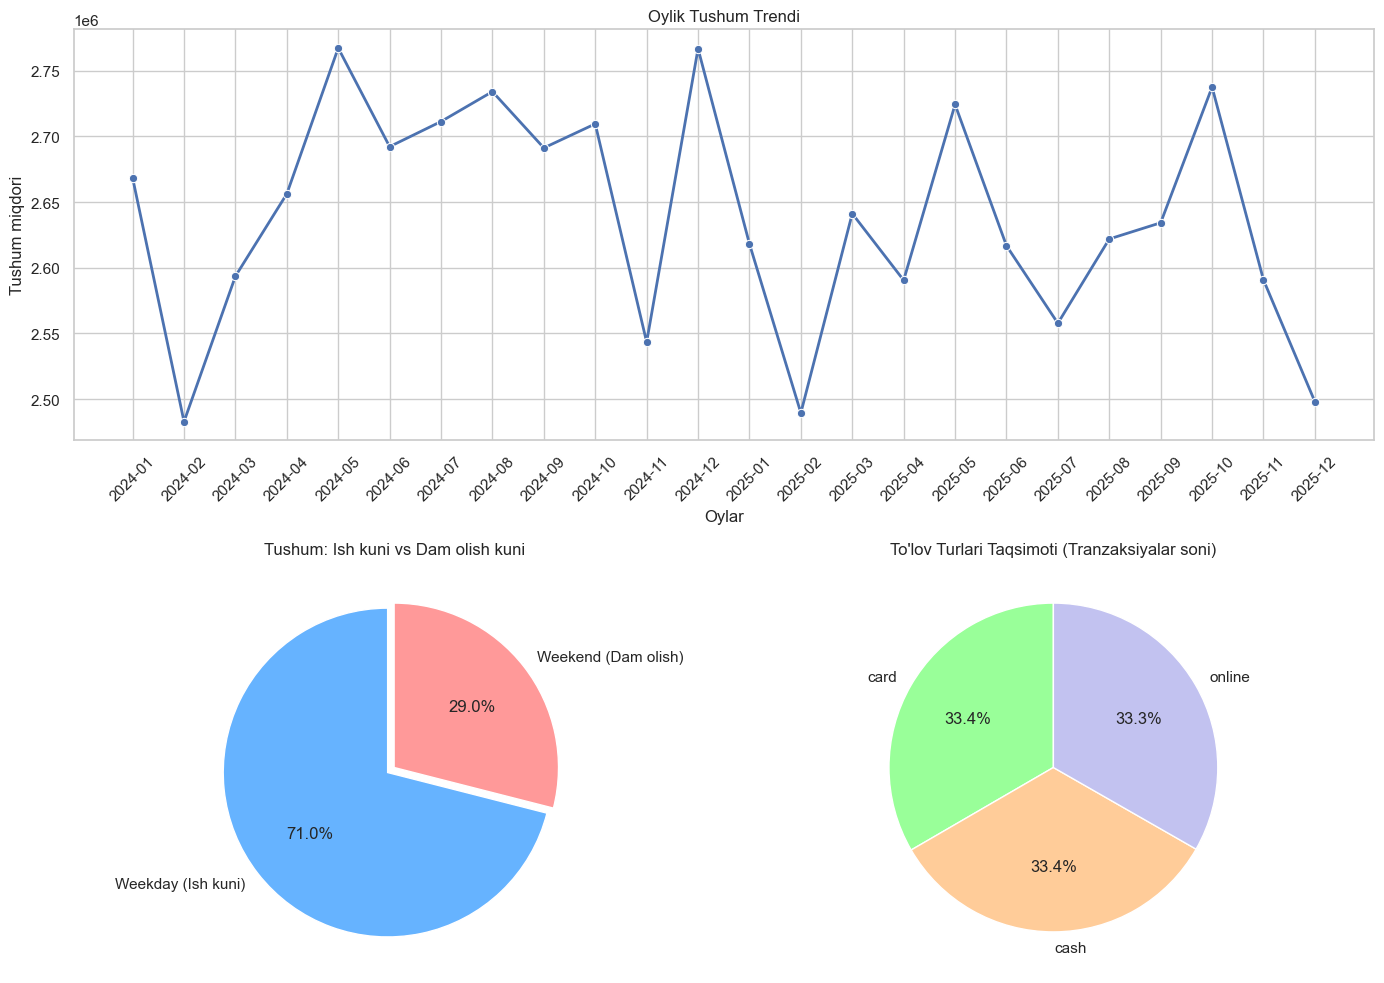

In [10]:
# Sanalardan oy nomini va hafta kunini ajratib olish
merged_df['month'] = merged_df['order_date'].dt.to_period('M').astype(str)
merged_df['day_of_week'] = merged_df['order_date'].dt.dayofweek

# 5 va 6 - Shanba hamda Yakshanba kunlari hisoblanadi
merged_df['day_type'] = merged_df['day_of_week'].isin([5, 6]).map({True: 'Weekend (Dam olish)', False: 'Weekday (Ish kuni)'})

# Ma'lumotlarni guruhlash
monthly_trend = merged_df.groupby('month')['revenue'].sum()
weekend_vs_weekday = merged_df.groupby('day_type')['revenue'].sum()
payment_distribution = merged_df['payment_type'].value_counts()

# Vizualizatsiya oynasi (Tepada 1 ta uzun grafik, pastda 2 ta doiraviy grafik)
fig = plt.figure(figsize=(14, 10))

# 1. Oylik trend (Chiziqli grafik)
ax1 = fig.add_subplot(2, 1, 1)
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o', color='b', ax=ax1, linewidth=2)
ax1.set_title("Oylik Tushum Trendi")
ax1.set_ylabel("Tushum miqdori")
ax1.set_xlabel("Oylar")
plt.xticks(rotation=45)

# 2. Ish kuni va Dam olish kuni (Doiraviy grafik)
ax2 = fig.add_subplot(2, 2, 3)
ax2.pie(weekend_vs_weekday, labels=weekend_vs_weekday.index, autopct='%1.1f%%', 
        colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0.05, 0))
ax2.set_title("Tushum: Ish kuni vs Dam olish kuni")

# 3. To'lov turlari (Doiraviy grafik)
ax3 = fig.add_subplot(2, 2, 4)
ax3.pie(payment_distribution, labels=payment_distribution.index, autopct='%1.1f%%', 
        colors=['#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6'], startangle=90)
ax3.set_title("To'lov Turlari Taqsimoti (Tranzaksiyalar soni)")

plt.tight_layout()
plt.show()

2-bosqich (Data Analytics) bo'yicha umumiy biznes xulosasi.

Tahlil natijasida olingan metrikalar va grafiklar biznesning joriy holatini baholash hamda kelajakdagi strategik qadamlarni belgilab olish uchun muhim poydevor vazifasini o'taydi. Otkazilgan tahlillar asosida quyidagi asosiy xulosalarni chiqarish mumkin:

Moliyaviy holat va samaradorlik:
Umumiy tushum, xarajatlar va sof foyda hisoblanib, biznesning real holati raqamlarda ko'rsatib berildi. Foyda marjasi (Profit Margin) orqali har bir sotilgan mahsulotdan qancha foiz sof daromad qolayotgani aniqlandi. Bu ko'rsatkich kelgusida narx siyosatini belgilashda asosiy mezon bo'ladi.

Asosiy daromad manbalari va zaif nuqtalar:
Tushumning asosiy qismini ta'minlayotgan Top 10 mahsulot va eng yuqori foyda keltiruvchi toifa (category) aniqlandi. Ushbu yo'nalishlarda zaxiralarni doimiy ta'minlash va kengaytirish tavsiya etiladi. Shu bilan birga, eng past ko'rsatkichga ega bo'lgan hudud (region) aniqlandi. Bu hududda sotuvlarni oshirish uchun marketing kampaniyalarini kuchaytirish yoki yetkazib berish jarayonlarini qayta ko'rib chiqish talab etiladi.

Mijozlar xatti-harakati va vaqt trendlari:
Oylik sotuv dinamikasi mavsumiy o'zgarishlar va o'sish nuqtalarini yaqqol ko'rsatib berdi. Ish kunlari va dam olish kunlaridagi xaridlar o'rtasidagi farq aniqlandi, bu esa aksiyalar yoki chegirmalarni qaysi kunlarda o'tkazish samaraliroq ekanligini bildiradi. Shuningdek, mijozlar orasida eng ommabop to'lov usullari (Payment type) taqsimoti aniqlandi, bu moliyaviy operatsiyalarni qaysi tizimlar orqali ko'proq amalga oshirish qulayligini ko'rsatadi.

# Forecasting


In [11]:

df = merged_df.copy()
df['year_month'] = df['order_date'].dt.to_period('M')

In [12]:
# 1. Umumiy oylik ko'rsatkichlar
monthly = df.groupby('year_month').agg(
    revenue  = ('revenue',  'sum'),
    quantity = ('quantity', 'sum'),
    profit   = ('profit',   'sum')
).reset_index()

monthly['year_month'] = monthly['year_month'].dt.to_timestamp()
monthly = monthly.sort_values('year_month')

print("=== OYLIK UMUMIY KO'RSATKICHLAR ===")
print(monthly.to_string(index=False))

# 2. Kategoriya bo'yicha oylik revenue
cat_monthly = df.groupby(['year_month', 'category'])['revenue'].sum().reset_index()
cat_monthly['year_month'] = cat_monthly['year_month'].dt.to_timestamp()
cat_monthly = cat_monthly.sort_values(['category', 'year_month'])

print("\n=== KATEGORIYA BO'YICHA OYLIK REVENUE (dastlabki 10 qator) ===")
print(cat_monthly.head(10).to_string(index=False))

=== OYLIK UMUMIY KO'RSATKICHLAR ===
year_month    revenue  quantity    profit
2024-01-01 2668485.26     15193 836080.96
2024-02-01 2482840.32     14103 780609.02
2024-03-01 2593573.92     15087 814042.42
2024-04-01 2656318.18     14992 831391.68
2024-05-01 2767374.67     15492 845402.37
2024-06-01 2692257.42     14545 838503.52
2024-07-01 2711393.39     15243 841699.89
2024-08-01 2734178.07     15465 844131.47
2024-09-01 2691305.04     14558 827439.94
2024-10-01 2709617.11     15549 832832.11
2024-11-01 2543404.26     14583 789600.56
2024-12-01 2766891.43     15273 870889.13
2025-01-01 2618236.61     15242 817058.41
2025-02-01 2489496.18     14000 775327.38
2025-03-01 2641288.47     15399 815316.87
2025-04-01 2590524.73     14445 805232.53
2025-05-01 2724364.75     15081 850711.35
2025-06-01 2616832.83     14919 818964.03
2025-07-01 2557772.21     14999 789831.91
2025-08-01 2621955.14     15336 816613.64
2025-09-01 2634289.78     14867 812320.98
2025-10-01 2737606.90     15622 842385.5

In [13]:
from sklearn.linear_model import LinearRegression

def forecast_next_month(data, date_col, value_col, label):
    data = data.sort_values(date_col).reset_index(drop=True)
    X = np.array(data.index + 1).reshape(-1, 1)
    y = data[value_col].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    next_month_num = np.array([[len(data) + 1]])
    forecast = model.predict(next_month_num)[0]
    r2 = model.score(X, y)
    
    print(f"{label:30s} | Prognoz: {forecast:>12,.0f} | R2 score: {r2:.3f}")
    return forecast

print("=== 2026-YANVAR PROGNOZI (Linear Regression) ===")
header = "Ko'rsatkich"
print(f"{header:30s} | {'Prognoz':>12s} | Aniqlik")
print("-" * 60)

# Umumiy ko'rsatkichlar
rev_forecast  = forecast_next_month(monthly, 'year_month', 'revenue',  'Revenue ($)')
qty_forecast  = forecast_next_month(monthly, 'year_month', 'quantity', 'Quantity (dona)')
prof_forecast = forecast_next_month(monthly, 'year_month', 'profit',   'Profit ($)')

print("-" * 60)

# Kategoriya bo'yicha
print("\n--- KATEGORIYALAR BO'YICHA ---")
categories = cat_monthly['category'].unique()
for cat in sorted(categories):
    cat_data = cat_monthly[cat_monthly['category'] == cat].copy()
    forecast_next_month(cat_data, 'year_month', 'revenue', f'{cat} Revenue ($)')

=== 2026-YANVAR PROGNOZI (Linear Regression) ===
Ko'rsatkich                    |      Prognoz | Aniqlik
------------------------------------------------------------
Revenue ($)                    | Prognoz:    2,608,101 | R2 score: 0.043
Quantity (dona)                | Prognoz:       15,025 | R2 score: 0.003
Profit ($)                     | Prognoz:      808,529 | R2 score: 0.069
------------------------------------------------------------

--- KATEGORIYALAR BO'YICHA ---
Accessories Revenue ($)        | Prognoz:       31,754 | R2 score: 0.096
Electronics Revenue ($)        | Prognoz:    2,115,499 | R2 score: 0.080
Fashion Revenue ($)            | Prognoz:       66,016 | R2 score: 0.008
Furniture Revenue ($)          | Prognoz:      391,898 | R2 score: 0.119
Stationery Revenue ($)         | Prognoz:        2,935 | R2 score: 0.150


In [14]:
def forecast_moving_average(data, date_col, value_col, label, window=3):
    data = data.sort_values(date_col).reset_index(drop=True)
    y = data[value_col].values
    
   
    forecast = np.mean(y[-window:])
    
    
    errors = []
    for i in range(6, len(y)):
        predicted = np.mean(y[i-window:i])
        actual = y[i]
        errors.append(abs(predicted - actual) / actual * 100)
    mape = np.mean(errors)
    
    print(f"{label:30s} | Prognoz: {forecast:>12,.0f} | Xato: {mape:.1f}%")
    return forecast

print("=== 2026-YANVAR PROGNOZI (Moving Average, 3 oy) ===")
header = "Ko'rsatkich"
print(f"{header:30s} | {'Prognoz':>12s} | O'rtacha xato")
print("-" * 62)

rev_ma  = forecast_moving_average(monthly, 'year_month', 'revenue',  'Revenue ($)')
qty_ma  = forecast_moving_average(monthly, 'year_month', 'quantity', 'Quantity (dona)')
prof_ma = forecast_moving_average(monthly, 'year_month', 'profit',   'Profit ($)')

print("-" * 62)
print("\n--- KATEGORIYALAR BO'YICHA ---")
for cat in sorted(cat_monthly['category'].unique()):
    cat_data = cat_monthly[cat_monthly['category'] == cat].copy()
    forecast_moving_average(cat_data, 'year_month', 'revenue', f'{cat} Revenue ($)')

print("\n=== TAQQOSLASH: Linear Regression vs Moving Average ===")
comparison_header = "Ko'rsatkich"
print(f"{comparison_header:20s} | {'Lin.Reg':>12s} | {'Mov.Avg':>12s}")
print("-" * 50)
print(f"{'Revenue ($)':20s} | {rev_forecast:>12,.0f} | {rev_ma:>12,.0f}")
print(f"{'Quantity (dona)':20s} | {qty_forecast:>12,.0f} | {qty_ma:>12,.0f}")
print(f"{'Profit ($)':20s} | {prof_forecast:>12,.0f} | {prof_ma:>12,.0f}")

=== 2026-YANVAR PROGNOZI (Moving Average, 3 oy) ===
Ko'rsatkich                    |      Prognoz | O'rtacha xato
--------------------------------------------------------------
Revenue ($)                    | Prognoz:    2,608,807 | Xato: 2.6%
Quantity (dona)                | Prognoz:       15,081 | Xato: 2.7%
Profit ($)                     | Prognoz:      809,615 | Xato: 2.7%
--------------------------------------------------------------

--- KATEGORIYALAR BO'YICHA ---
Accessories Revenue ($)        | Prognoz:       32,890 | Xato: 5.8%
Electronics Revenue ($)        | Prognoz:    2,111,289 | Xato: 3.1%
Fashion Revenue ($)            | Prognoz:       66,674 | Xato: 5.0%
Furniture Revenue ($)          | Prognoz:      395,050 | Xato: 2.6%
Stationery Revenue ($)         | Prognoz:        2,904 | Xato: 5.2%

=== TAQQOSLASH: Linear Regression vs Moving Average ===
Ko'rsatkich          |      Lin.Reg |      Mov.Avg
--------------------------------------------------
Revenue ($)          |   